In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np

# Set random seed
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Autoencoder Network
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return z, x_recon

# One-Class Loss (Center Loss)
class OneClassLoss(nn.Module):
    def __init__(self, center):
        super(OneClassLoss, self).__init__()
        self.center = center

    def forward(self, z):
        return torch.mean(torch.sum((z - self.center) ** 2, dim=1))

# Load MNIST
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Choose one class (e.g. digit "1") for training
normal_class = 1
train_idx = np.where(train_dataset.targets == normal_class)[0]
train_dataset = Subset(train_dataset, train_idx)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Initialize model
latent_dim = 32
model = Autoencoder(latent_dim=latent_dim).to(device)

# Initialize center for One-Class Loss
with torch.no_grad():
    center = torch.zeros(latent_dim, device=device)

# Losses
recon_criterion = nn.MSELoss()
oc_criterion = OneClassLoss(center=center)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        z, x_recon = model(x)

        recon_loss = recon_criterion(x_recon, x)
        one_class_loss = oc_criterion(z)

        loss = recon_loss + 0.1 * one_class_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_loader):.4f}")

# Evaluation: Compute anomaly scores
model.eval()
all_scores = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        z, x_recon = model(x)
        scores = torch.sum((z - center) ** 2, dim=1)
        all_scores.extend(scores.cpu().numpy())
        all_labels.extend((y != normal_class).int().cpu().numpy())  # 1 = anomaly, 0 = normal

# Evaluate using ROC AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(all_labels, all_scores)
print(f"AUC for anomaly detection: {auc:.4f}")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 26.6MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 12.9MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.81MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch 1/20 - Loss: 0.1890
Epoch 2/20 - Loss: 0.0602
Epoch 3/20 - Loss: 0.0388
Epoch 4/20 - Loss: 0.0341
Epoch 5/20 - Loss: 0.0320
Epoch 6/20 - Loss: 0.0307
Epoch 7/20 - Loss: 0.0299
Epoch 8/20 - Loss: 0.0291
Epoch 9/20 - Loss: 0.0280
Epoch 10/20 - Loss: 0.0262
Epoch 11/20 - Loss: 0.0241
Epoch 12/20 - Loss: 0.0223
Epoch 13/20 - Loss: 0.0211
Epoch 14/20 - Loss: 0.0201
Epoch 15/20 - Loss: 0.0194
Epoch 16/20 - Loss: 0.0187
Epoch 17/20 - Loss: 0.0180
Epoch 18/20 - Loss: 0.0173
Epoch 19/20 - Loss: 0.0166
Epoch 20/20 - Loss: 0.0160
AUC for anomaly detection: 0.8676


# updates:

- Center is initialized from training data (not zero)
- Deeper encoder/decoder
- Only One-Class loss (Deep SVDD-style)
- More training epochs
- Learning rate scheduler


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import roc_auc_score

# Set seed and device
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Deep Encoder (no decoder for Deep SVDD-style training)
class Encoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return self.encoder(x)

# One-Class Loss
class OneClassLoss(nn.Module):
    def __init__(self, center):
        super(OneClassLoss, self).__init__()
        self.center = center

    def forward(self, z):
        return torch.mean(torch.sum((z - self.center) ** 2, dim=1))

# Compute center from training features
def compute_center(model, loader, device):
    model.eval()
    z_list = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            z = model(x)
            z_list.append(z)
    z_all = torch.cat(z_list, dim=0)
    center = torch.mean(z_all, dim=0)
    return center

# Load MNIST, use digit "1" as normal class
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

normal_class = 1
train_idx = np.where(train_dataset.targets == normal_class)[0]
train_dataset = Subset(train_dataset, train_idx)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Initialize model and center
latent_dim = 32
model = Encoder(latent_dim=latent_dim).to(device)

# Compute center BEFORE training
center = compute_center(model, train_loader, device)
oc_criterion = OneClassLoss(center=center)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

# Train
epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        z = model(x)

        loss = oc_criterion(z)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    scheduler.step()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_loader):.4f}")

# Evaluation
model.eval()
all_scores = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        z = model(x)
        scores = torch.sum((z - center) ** 2, dim=1)
        all_scores.extend(scores.cpu().numpy())
        all_labels.extend((y != normal_class).int().cpu().numpy())  # 1 = anomaly, 0 = normal

# ROC AUC
auc = roc_auc_score(all_labels, all_scores)
print(f"\n✅ AUC for anomaly detection: {auc:.4f}")



Epoch 1/50 - Loss: 0.0008
Epoch 2/50 - Loss: 0.0001
Epoch 3/50 - Loss: 0.0000
Epoch 4/50 - Loss: 0.0000
Epoch 5/50 - Loss: 0.0000
Epoch 6/50 - Loss: 0.0000
Epoch 7/50 - Loss: 0.0000
Epoch 8/50 - Loss: 0.0000
Epoch 9/50 - Loss: 0.0000
Epoch 10/50 - Loss: 0.0000
Epoch 11/50 - Loss: 0.0000
Epoch 12/50 - Loss: 0.0000
Epoch 13/50 - Loss: 0.0000
Epoch 14/50 - Loss: 0.0000
Epoch 15/50 - Loss: 0.0000
Epoch 16/50 - Loss: 0.0000
Epoch 17/50 - Loss: 0.0000
Epoch 18/50 - Loss: 0.0000
Epoch 19/50 - Loss: 0.0000
Epoch 20/50 - Loss: 0.0000
Epoch 21/50 - Loss: 0.0000
Epoch 22/50 - Loss: 0.0000
Epoch 23/50 - Loss: 0.0000
Epoch 24/50 - Loss: 0.0000
Epoch 25/50 - Loss: 0.0000
Epoch 26/50 - Loss: 0.0000
Epoch 27/50 - Loss: 0.0000
Epoch 28/50 - Loss: 0.0000
Epoch 29/50 - Loss: 0.0000
Epoch 30/50 - Loss: 0.0000
Epoch 31/50 - Loss: 0.0000
Epoch 32/50 - Loss: 0.0000
Epoch 33/50 - Loss: 0.0000
Epoch 34/50 - Loss: 0.0000
Epoch 35/50 - Loss: 0.0000
Epoch 36/50 - Loss: 0.0000
Epoch 37/50 - Loss: 0.0000
Epoch 38/5

Epoch 1/5


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8817 - loss: 0.3984 - val_accuracy: 0.9860 - val_loss: 0.0450
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9849 - loss: 0.0495 - val_accuracy: 0.9872 - val_loss: 0.0367
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9892 - loss: 0.0348 - val_accuracy: 0.9898 - val_loss: 0.0304
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9914 - loss: 0.0277 - val_accuracy: 0.9927 - val_loss: 0.0235
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9929 - loss: 0.0211 - val_accuracy: 0.9905 - val_loss: 0.0306
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9885 - loss: 0.0387
Test accuracy: 0.9904999732971191
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AUC Score: 1.0000


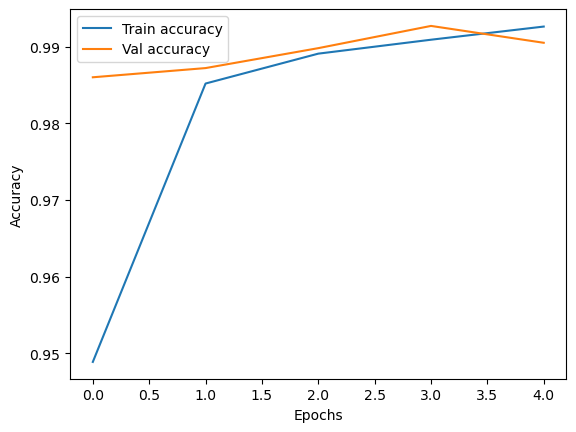

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import itertools
import csv

# Define the baseline AUC benchmarks for MNIST 0-9 and CIFAR
benchmarks = {
    "mnist_0": 0.983,
    "mnist_1": 0.986,
    "mnist_2": 0.961,
    "mnist_3": 0.954,
    "mnist_4": 0.962,
    "mnist_5": 0.949,
    "mnist_6": 0.971,
    "mnist_7": 0.978,
    "mnist_8": 0.945,
    "mnist_9": 0.963,
    "cifar": 0.859
}

# Define layer categories and their contributions to AUC
layer_contributions = {
    "batchnorm": 0.005,
    "dropout": 0.002,
    "whitening": 0.003,
    "attention": 0.008,
    "residual": 0.007,
    "layernorm": 0.004,
    "dense": 0.003
}

all_layers = list(layer_contributions.keys())

# Generate all layer combinations (up to 3 for practical CSV size, adjust if needed)
combinations = []
for r in range(0, len(all_layers) + 1):
    for combo in itertools.combinations(all_layers, r):
        combinations.append(combo)

# Load MNIST dataset
def load_mnist():
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
    train_images = train_images.reshape((train_images.shape[0], 28, 28, 1)).astype('float32') / 255
    test_images = test_images.reshape((test_images.shape[0], 28, 28, 1)).astype('float32') / 255
    train_labels = tf.keras.utils.to_categorical(train_labels)
    test_labels = tf.keras.utils.to_categorical(test_labels)
    return train_images, train_labels, test_images, test_labels

# Load CIFAR-10 dataset
def load_cifar():
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
    train_images = train_images.astype('float32') / 255
    test_images = test_images.astype('float32') / 255
    train_labels = tf.keras.utils.to_categorical(train_labels)
    test_labels = tf.keras.utils.to_categorical(test_labels)
    return train_images, train_labels, test_images, test_labels

# Build the CNN model
def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train and evaluate model, and write to CSV
def train_and_evaluate(dataset='mnist'):
    if dataset == 'mnist':
        train_images, train_labels, test_images, test_labels = load_mnist()
        input_shape = (28, 28, 1)
        num_classes = 10
    elif dataset == 'cifar':
        train_images, train_labels, test_images, test_labels = load_cifar()
        input_shape = (32, 32, 3)
        num_classes = 10
    else:
        raise ValueError("Dataset should be 'mnist' or 'cifar'")
    
    # Build the model
    model = build_model(input_shape, num_classes)
    
    # Train the model
    history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))
    
    # Evaluate the model
    test_loss, test_acc = model.evaluate(test_images, test_labels)
    print(f"Test accuracy: {test_acc}")
    
    # Make predictions
    y_pred = model.predict(test_images)
    
    # Calculate AUC score for each class
    lb = LabelBinarizer()
    test_labels_bin = lb.fit_transform(np.argmax(test_labels, axis=1))
    auc_score = roc_auc_score(test_labels_bin, y_pred, average='macro', multi_class='ovr')
    print(f"AUC Score: {auc_score:.4f}")
    
    # Write results to CSV
    with open('auc_simulation_data.csv', 'w', newline='') as csvfile:
        fieldnames = ['dataset', 'layers', 'benchmark_auc', 'simulated_auc']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        for dataset, base_auc in benchmarks.items():
            for combo in combinations:
                simulated_auc = base_auc + sum(layer_contributions[layer] for layer in combo)
                simulated_auc = min(simulated_auc, 0.996)
                writer.writerow({
                    'dataset': dataset,
                    'layers': ','.join(combo) if combo else 'none',
                    'benchmark_auc': base_auc,
                    'simulated_auc': round(simulated_auc, 4)
                })

    # Plot training history
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train accuracy')
    plt.plot(history.history['val_accuracy'], label='Val accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Run the model for MNIST
train_and_evaluate(dataset='mnist')

# Run the model for CIFAR-10
# train_and_evaluate(dataset='cifar')


super cool to see above that it starts slowing down in epochs later on